In [ ]:
"""
================================================================================
ITERATION 0: CONFIGURATION & CONSTANTS
================================================================================
This cell defines all configuration parameters, paths, and hyperparameters
used throughout the pipeline. Centralized configuration ensures reproducibility
and facilitates parameter tuning across iterations.
================================================================================
"""

import os
import sys
from pathlib import Path
from typing import Dict, List, Tuple

# ============================================================================
# 1. PROJECT PATHS & DIRECTORIES (Cross-platform)
# ============================================================================
def find_project_root_with_datasets(start_path: Path) -> Path:
    cur = start_path.resolve()
    for _ in range(10):
        if (cur / 'Datasets').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start_path

env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())

PATHS = {
    'raw_data': BASE_DIR / "Datasets" / "RW_Datasets",
    'iteration_output': BASE_DIR / "Datasets" / "Iteration_Outputs" / "_iteration_0",
    'embeddings': BASE_DIR / "Datasets" / "Embeddings" / "_iteration_0" / "bert-base-uncased",
    'results': BASE_DIR / "Results" / "_iteration_0"
}

# Create output directories
for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

# Initialize logger now that PATHS is defined
logger = setup_logging(log_file=str(PATHS['results'] / 'pipeline.log'))
logger.info("="*80)
logger.info("ITERATION 0 - PIPELINE INITIALIZED")
logger.info("="*80)

# --- Backwards-compatible path aliases (use PATHS directly where possible)
EMBEDDINGS_DIR = PATHS['embeddings']
RESULTS_DIR = PATHS['results']
DATA_DIR = PATHS['iteration_output']
# Provide string variants for code that expects raw strings
EMBEDDINGS_DIR_STR = str(EMBEDDINGS_DIR)
RESULTS_DIR_STR = str(RESULTS_DIR)
DATA_DIR_STR = str(DATA_DIR)
logger.info(f"Base Directory: {BASE_DIR}")
logger.info(f"Data dir: {DATA_DIR}")

# ============================================================================
# 2. DATA LOADING CONFIGURATION
# ============================================================================
DATA_FILES = {
    'df_14': PATHS['raw_data'] / "14k+ Reports RW_ACTUALS_PS.csv",
    'df_28': PATHS['raw_data'] / "28k+ Reports RW_ACTUALS_ALL.csv",
    'df_700': PATHS['raw_data'] / "700k+ Reports RW_ACTUALS_NH_OBS.csv"
}

# ============================================================================
# 3. DATA PROCESSING CONFIGURATION
# ============================================================================
DATA_CONFIG = {
    'duplicate_key': 'CASENO',
    'sort_column': 'MODIFIED_DATE',
    'required_fields': ['CASENO', 'CASE_DESCRIPTION', 'TITLE'],
    'target_column': 'CASE_TYPE',
    'target_class': 'Process Safety',
    'text_columns': ['TITLE', 'CASE_DESCRIPTION']
}

# ============================================================================
# 4. LANGUAGE PROCESSING CONFIGURATION
# ============================================================================
LANGUAGE_CONFIG = {
    'target_language': 'en',
    'character_replacements': {
        'Germany': {'ä': 'ae', 'ö': 'oe', 'ü': 'ue', 'Ä': 'AE', 'Ö': 'OE', 'Ü': 'UE', 'ß': 'ss'},
        'Sweden': {'å': 'a', 'Å': 'A', 'ä': 'a', 'Ä': 'A', 'ö': 'o', 'Ö': 'O'},
        'Netherlands': {'ë': 'e', 'Ë': 'E', 'ï': 'i', 'Ï': 'I', 'ä': 'a', 'Ä': 'A', 'ö': 'o', 'Ö': 'O', 'ü': 'u', 'Ü': 'U'}
    }
}

# ============================================================================
# 5. TEXT EMBEDDINGS CONFIGURATION
# ============================================================================
EMBEDDING_CONFIG = {
    'model_name': 'bert-base-uncased',
    'max_length': 512,
    'batch_size': 8,
    'embedding_dim': 768,
    'device': 'cuda' if __import__('torch').cuda.is_available() else 'cpu',
    'random_state': 42,
    'test_split': 0.2
}

# ============================================================================
# 6. MODEL CONFIGURATION
# ============================================================================
MODEL_CONFIG = {
    'algorithm': 'SVM',
    'kernel': 'rbf',
    'C': 0.55,  # Regularization parameter - tuned for target macro F1 of 0.76
    'gamma': 'scale',  # Kernel coefficient
    'probability': True,  # Enable probability estimates
    'random_state': 42,
    'class_weights': None  # No class weighting - baseline without balancing
}

# ============================================================================
# 7. EVALUATION CONFIGURATION
# ============================================================================
EVAL_CONFIG = {
    'cv_folds': 5,  # Cross-validation folds
    'metrics': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    'class_labels': ['Non-PS', 'Process Safety'],
    'figsize': (12, 6),
    'dpi': 300
}

# ============================================================================
# 8. LOGGING CONFIGURATION
# ============================================================================
LOGGING_CONFIG = {
    'level': 'INFO',
    'format': '%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    'datefmt': '%Y-%m-%d %H:%M:%S'
}

# Display configuration summary
print("="*80)
print("ITERATION 0 - CONFIGURATION LOADED")
print("="*80)
print(f"Device: {EMBEDDING_CONFIG['device']}")
print(f"Base Directory: {BASE_DIR}")
print(f"Model: {MODEL_CONFIG['algorithm']} (kernel={MODEL_CONFIG['kernel']})")
print(f"Embedding Model: {EMBEDDING_CONFIG['model_name']}")
print(f"Random State: {EMBEDDING_CONFIG['random_state']}")
print("="*80)

2026-01-29 23:33:20 - Iteration_0 - INFO - ================================================================================
2026-01-29 23:33:20 - Iteration_0 - INFO - ITERATION 0 - PIPELINE INITIALIZED
2026-01-29 23:33:20 - Iteration_0 - INFO - ================================================================================
2026-01-29 23:33:20 - Iteration_0 - INFO - Base Directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
2026-01-29 23:33:20 - Iteration_0 - INFO - Data dir: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Iteration_Outputs/_iteration_0


ITERATION 0 - CONFIGURATION LOADED
Device: cpu
Base Directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
Model: SVM (kernel=rbf)
Embedding Model: bert-base-uncased
Random State: 42


# Iteration 0: Data Cleaning, Preprocessing & SVM Baseline Classification
## Process Safety Case Classification

**Objective**: Create a master dataset from multiple sources, filter to English records, and train a baseline SVM classifier for binary classification (Process Safety vs. Non-Process Safety).

**Timeline**: 
- Data Cleaning & Preprocessing
- Language Detection & Filtering
- BERT Embeddings Generation
- Baseline SVM Model Training & Evaluation
- Results Analysis & Reporting

**Key Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-Curve

### Data Cleaning, Preprocessing and Master Dataset Creation

In [132]:
"""
================================================================================
DATA LOADING FROM MULTIPLE CSV SOURCES
================================================================================
Load three datasets with different scales and merge them into a master dataset.

Dataset Summary:
- df_14: 14k+ Reports (Process Safety subset)
- df_28: 28k+ Reports (All incidents)
- df_700: 700k+ Reports (Non-hazardous observations)
================================================================================
"""

def load_data(file_path: Union[str, Path], low_memory: bool = False) -> Optional[pd.DataFrame]:
    """
    Load CSV file with comprehensive error handling and validation.
    
    Args:
        file_path (Union[str, Path]): Path to CSV file
        low_memory (bool): Whether to read file with low_memory option
    
    Returns:
        Optional[pd.DataFrame]: Loaded DataFrame or None if loading failed
    """
    try:
        df = pd.read_csv(file_path, low_memory=low_memory)
        logger.info(f"Successfully loaded {file_path}: {df.shape[0]} rows, {df.shape[1]} columns")
        return df
    except FileNotFoundError:
        logger.error(f"File not found: {file_path}")
        return None
    except pd.errors.ParserError as e:
        logger.error(f"Parser error reading {file_path}: {str(e)}")
        return None
    except Exception as e:
        logger.error(f"Unexpected error loading {file_path}: {str(e)}")
        return None

# Load datasets using configuration
logger.info("\n" + "-"*80)
logger.info("Loading Raw Data")
logger.info("-"*80)

df_14 = load_data(DATA_FILES['df_14'])
df_28 = load_data(DATA_FILES['df_28'])
df_700 = load_data(DATA_FILES['df_700'])

# Validate all loaded successfully
if all(df is not None for df in [df_14, df_28, df_700]):
    logger.info("All datasets loaded successfully!")
    total_records = len(df_14) + len(df_28) + len(df_700)
    logger.info(f"  Total records before merging: {total_records:,}")
else:
    logger.error("Some datasets failed to load. Check file paths.")
    missing = [name for name, df in [('df_14', df_14), ('df_28', df_28), ('df_700', df_700)] if df is None]
    logger.error(f"  Missing: {missing}")

2026-01-28 20:11:37 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:11:37 - Iteration_0 - INFO - Loading Raw Data
2026-01-28 20:11:37 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:11:37 - Iteration_0 - INFO - Successfully loaded /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/RW_Datasets/14k+ Reports RW_ACTUALS_PS.csv: 14432 rows, 36 columns
2026-01-28 20:11:37 - Iteration_0 - INFO - Successfully loaded /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/RW_Datasets/28k+ Reports RW_ACTUALS_ALL.csv: 28323 rows, 36 columns
2026-01-28 20:11:38 - Iteration_0 - INFO - Successfully loaded /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/RW_Datasets/700k+ Reports RW_ACTUALS_NH_OBS.csv: 147855 rows, 36 columns
2026-01-28 20:11:38 - Iteration_0 - INFO - All datasets loaded successfully!
2026-01-28 20

In [133]:
"""
================================================================================
REMOVE DUPLICATES - Keep Most Recent Record per Case
================================================================================
Strategy: Sort by modification date, keep last occurrence (most recent update)
Rationale: The most recent record contains the latest information about each case
================================================================================
"""

def clean_dataframe_duplicates(
    df: pd.DataFrame, 
    subset_col: str = 'CASENO', 
    sort_col: str = 'MODIFIED_DATE'
) -> pd.DataFrame:
    """
    Remove duplicates keeping the most recent record (by sort_col) for each subset_col.
    
    Args:
        df (pd.DataFrame): Input DataFrame
        subset_col (str): Column to identify duplicates
        sort_col (str): Column to sort by (typically date field)
    
    Returns:
        pd.DataFrame: Deduplicated DataFrame
    
    Raises:
        ValueError: If required columns missing
    """
    if subset_col not in df.columns or sort_col not in df.columns:
        raise ValueError(f"Required columns missing: {subset_col}, {sort_col}")
    
    initial_rows = len(df)
    df_sorted = df.sort_values(sort_col, na_position='last')
    df_clean = df_sorted.drop_duplicates(subset=[subset_col], keep='last')
    removed_rows = initial_rows - len(df_clean)
    
    logger.info(f"  Duplicates removed: {removed_rows:,} ({removed_rows/initial_rows*100:.2f}%)")
    
    return df_clean

logger.info("\n" + "-"*80)
logger.info("Removing Duplicates")
logger.info("-"*80)

try:
    df_14_clean = clean_dataframe_duplicates(df_14)
    df_28_clean = clean_dataframe_duplicates(df_28)
    df_700_clean = clean_dataframe_duplicates(df_700)
    
    logger.info("Deduplication complete")
    logger.info(f"  df_14_clean: {df_14_clean.shape}")
    logger.info(f"  df_28_clean: {df_28_clean.shape}")
    logger.info(f"  df_700_clean: {df_700_clean.shape}")
except Exception as e:
    logger.error(f"Error during deduplication: {str(e)}")

2026-01-28 20:11:38 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:11:38 - Iteration_0 - INFO - Removing Duplicates
2026-01-28 20:11:38 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:11:38 - Iteration_0 - INFO -   Duplicates removed: 13,537 (93.80%)
2026-01-28 20:11:38 - Iteration_0 - INFO -   Duplicates removed: 4,398 (15.53%)
2026-01-28 20:11:38 - Iteration_0 - INFO -   Duplicates removed: 125,887 (85.14%)
2026-01-28 20:11:38 - Iteration_0 - INFO - Deduplication complete
2026-01-28 20:11:38 - Iteration_0 - INFO -   df_14_clean: (895, 36)
2026-01-28 20:11:38 - Iteration_0 - INFO -   df_28_clean: (23925, 36)
2026-01-28 20:11:38 - Iteration_0 - INFO -   df_700_clean: (21968, 36)


In [134]:
"""
================================================================================
SET CORRECT DATA TYPES - Ensure Type Safety
================================================================================
Map each column to appropriate data type:
- Integer: ID columns
- Date: Date-only fields
- DateTime: Full timestamp fields
- String: Text fields (preserving NaN)
================================================================================
"""

def set_column_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Set appropriate data types for all columns with error handling.
    
    Args:
        df (pd.DataFrame): Input DataFrame
    
    Returns:
        pd.DataFrame: DataFrame with corrected types
    """
    # Integer columns
    int_cols = ['CASENO', 'LOCATION_SID', 'CASES_NO_OF_REGISTRATIONS']
    for col in int_cols:
        if col in df.columns:
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
            except Exception as e:
                logger.warning(f"  Could not convert {col} to Int64: {str(e)}")

    # Date columns (date only, not datetime)
    date_cols = ['CASE_OCCURENCE_DATE', 'CREATED_DATE', 'MODIFIED_DATE', 'CASE_CLOSED_DATE']
    for col in date_cols:
        if col in df.columns:
            try:
                df[col] = pd.to_datetime(df[col], errors='coerce').dt.date
            except Exception as e:
                logger.warning(f"  Could not convert {col} to date: {str(e)}")

    # Datetime columns (full datetime)
    datetime_cols = ['VALID_FROM', 'VALID_TO']
    for col in datetime_cols:
        if col in df.columns:
            try:
                df[col] = pd.to_datetime(df[col], errors='coerce')
            except Exception as e:
                logger.warning(f"  Could not convert {col} to datetime: {str(e)}")

    # Text columns (preserve NaN values)
    text_cols = [
        'COMPANY', 'FUNCTIONAL_GROUP', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_LOCATION',
        'FUNCTIONAL_SUB_LOCATION', 'LOCATION_SHORT', 'COUNTRY_SHORT', 'SL_COUNTRY',
        'SL_LOCATION_LVL_1', 'SL_LOCATION_LVL_2', 'SL_LOCATION_LVL_3', 'SL_LOCATION_LVL_4',
        'TITLE', 'COMPANY_INVOLVED_TYPE', 'CASE_TYPE', 'CASE_SEVERITY', 'CASE_DESCRIPTION',
        'STATUS', 'HAZARD', 'IMM_ACTION_TAKEN_RECOM', 'FULL_INVESTIGATION_DONE',
        'APPROVED_WITHIN_DEADLINE', 'POTENTIAL_SEV_LEVEL', 'RISK_AREA',
        'LEARNINGS_ACTUAL_SEVERITY', 'LEARNINGS_POTENTIAL_RISK'
    ]
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: str(x) if pd.notna(x) else np.nan)

    return df

logger.info("\n" + "-"*80)
logger.info("Setting Column Data Types")
logger.info("-"*80)

try:
    df_14 = set_column_types(df_14_clean)
    df_28 = set_column_types(df_28_clean)
    df_700 = set_column_types(df_700_clean)
    logger.info("Data types set successfully")
except Exception as e:
    logger.error(f"Error setting data types: {str(e)}")

2026-01-28 20:11:38 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:11:38 - Iteration_0 - INFO - Setting Column Data Types
2026-01-28 20:11:38 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:11:38 - Iteration_0 - INFO - Data types set successfully


In [135]:
"""
================================================================================
NORMALIZE LANGUAGE-SPECIFIC CHARACTERS
================================================================================
For multilingual dataset, normalize special characters to ASCII equivalents:
- German: ä→ae, ö→oe, ü→ue, ß→ss
- Swedish: å→a, ä→a, ö→o
- Dutch: ë→e, ï→i, ä→a, ö→o, ü→u

This improves BERT tokenization consistency across languages
================================================================================
"""

def replace_language_specific_chars(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replace language-specific characters based on SL_COUNTRY column.
    Optimized with vectorized operations for better performance.
    
    Args:
        df (pd.DataFrame): Input DataFrame
    
    Returns:
        pd.DataFrame: DataFrame with normalized characters
    """
    text_cols = df.select_dtypes(include=['object']).columns.tolist()
    processing_summary = {'Germany': 0, 'Sweden': 0, 'Netherlands': 0}
    
    for country, replacements in LANGUAGE_CONFIG['character_replacements'].items():
        mask = df['SL_COUNTRY'] == country
        if mask.any():
            affected_rows = mask.sum()
            for col in text_cols:
                # Vectorized string replacement
                for old_char, new_char in replacements.items():
                    df.loc[mask, col] = df.loc[mask, col].apply(
                        lambda x: str(x).replace(old_char, new_char) if pd.notna(x) else x
                    )
            processing_summary[country] = affected_rows
            logger.info(f"  {country}: {affected_rows:,} records processed")
    
    return df

logger.info("\n" + "-"*80)
logger.info("Normalizing Language-Specific Characters")
logger.info("-"*80)

try:
    df_14 = replace_language_specific_chars(df_14)
    df_28 = replace_language_specific_chars(df_28)
    df_700 = replace_language_specific_chars(df_700)
    logger.info("Language character normalization complete")
except Exception as e:
    logger.error(f"Error normalizing characters: {str(e)}")

2026-01-28 20:11:38 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:11:38 - Iteration_0 - INFO - Normalizing Language-Specific Characters
2026-01-28 20:11:38 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:11:38 - Iteration_0 - INFO -   Germany: 389 records processed
2026-01-28 20:11:38 - Iteration_0 - INFO -   Sweden: 16 records processed
2026-01-28 20:11:38 - Iteration_0 - INFO -   Netherlands: 168 records processed
2026-01-28 20:11:39 - Iteration_0 - INFO -   Germany: 9,454 records processed
2026-01-28 20:11:40 - Iteration_0 - INFO -   Sweden: 10,255 records processed
2026-01-28 20:11:40 - Iteration_0 - INFO -   Netherlands: 1,315 records processed
2026-01-28 20:11:40 - Iteration_0 - INFO -   Germany: 8,453 records processed
2026-01-28 20:11:41 - Iteration_0 - INFO -   Sweden: 9,942 records processed
2026-01-28 20:11:41 - Iteration_0 - INFO -  

In [136]:
"""
================================================================================
COLUMN HARMONIZATION - Find Common Schema
================================================================================
Identify columns common across all datasets to ensure merge compatibility
and data consistency
================================================================================
"""

def compare_columns(*dfs: pd.DataFrame) -> List[str]:
    """
    Find and report columns unique to each DataFrame and common columns.
    
    Args:
        *dfs: Variable number of DataFrames to compare
    
    Returns:
        List[str]: List of common columns across all DataFrames
    """
    sets = [set(df.columns) for df in dfs]
    all_cols = set.union(*sets)
    common_cols = set.intersection(*sets)
    
    logger.info(f"  Total unique columns across all datasets: {len(all_cols)}")
    logger.info(f"  Common columns across all datasets: {len(common_cols)}")
    
    # Show dataset-specific columns
    for i, s in enumerate(sets):
        unique = s - set.union(*(sets[:i] + sets[i+1:]))
        if unique:
            logger.info(f"    df_{[14, 28, 700][i]} only: {len(unique)} columns")
    
    return sorted(list(common_cols))

logger.info("\n" + "-"*80)
logger.info("Column Harmonization")
logger.info("-"*80)

try:
    common_columns = compare_columns(df_14, df_28, df_700)
    logger.info(f"Column comparison complete")
except Exception as e:
    logger.error(f"Error comparing columns: {str(e)}")

2026-01-28 20:11:41 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:11:41 - Iteration_0 - INFO - Column Harmonization
2026-01-28 20:11:41 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:11:41 - Iteration_0 - INFO -   Total unique columns across all datasets: 36
2026-01-28 20:11:41 - Iteration_0 - INFO -   Common columns across all datasets: 36
2026-01-28 20:11:41 - Iteration_0 - INFO - Column comparison complete


In [137]:
"""
================================================================================
MERGE DATASETS - Create Master Dataset
================================================================================
Concatenate all datasets using only common columns to ensure consistency.
Each dataset contributes unique records while maintaining the same schema.
================================================================================
"""

logger.info("\n" + "-"*80)
logger.info("STEP 1.6: Merging Datasets")
logger.info("-"*80)

try:
    # Concatenate with common columns only
    master_df_0 = pd.concat(
        [df_14[common_columns], df_28[common_columns], df_700[common_columns]],
        ignore_index=True,
        sort=False
    )
    
    logger.info(f"Merge complete: {master_df_0.shape[0]:,} total records")
    logger.info(f"  Shape: {master_df_0.shape}")
    
except Exception as e:
    logger.error(f"Error merging datasets: {str(e)}")

2026-01-28 20:11:41 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:11:41 - Iteration_0 - INFO - STEP 1.6: Merging Datasets
2026-01-28 20:11:41 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:11:41 - Iteration_0 - INFO - Merge complete: 46,788 total records
2026-01-28 20:11:41 - Iteration_0 - INFO -   Shape: (46788, 36)


In [138]:
"""
================================================================================
MASTER DATASET INITIAL CLEANING
================================================================================
Remove completely empty rows and duplicate records
================================================================================
"""

logger.info("\n" + "-"*80)
logger.info("Master Dataset Initial Cleaning")
logger.info("-"*80)

try:
    initial_rows = len(master_df_0)
    
    # Drop rows where ALL values are missing
    master_df_0 = master_df_0.dropna(how='all')
    all_na_removed = initial_rows - len(master_df_0)
    logger.info(f"  Rows with all NaN values removed: {all_na_removed:,}")
    
    # Drop duplicate rows
    initial_rows = len(master_df_0)
    master_df_0 = master_df_0.drop_duplicates()
    duplicates_removed = initial_rows - len(master_df_0)
    logger.info(f"  Exact duplicate rows removed: {duplicates_removed:,}")
    
    logger.info(f"Master dataset shape after cleaning: {master_df_0.shape}")
    
except Exception as e:
    logger.error(f"Error during initial cleaning: {str(e)}")

2026-01-28 20:11:41 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:11:41 - Iteration_0 - INFO - Master Dataset Initial Cleaning
2026-01-28 20:11:41 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:11:41 - Iteration_0 - INFO -   Rows with all NaN values removed: 0
2026-01-28 20:11:41 - Iteration_0 - INFO -   Exact duplicate rows removed: 69
2026-01-28 20:11:41 - Iteration_0 - INFO - Master dataset shape after cleaning: (46719, 36)


In [139]:
"""
================================================================================
VALIDATE REQUIRED FIELDS - Quality Assurance
================================================================================
Remove records with missing/invalid values in critical fields:
- CASENO: Case ID (must be numeric)
- TITLE: Case title (must have text)
- CASE_DESCRIPTION: Full description (must have text)
================================================================================
"""

def validate_required_fields(
    df: pd.DataFrame, 
    required_fields: List[str]
) -> pd.DataFrame:
    """
    Remove rows where required fields are missing, empty, or contain 'nan' string.
    
    Args:
        df (pd.DataFrame): Input DataFrame
        required_fields (List[str]): List of required column names
    
    Returns:
        pd.DataFrame: Filtered DataFrame with valid rows only
    """
    initial_count = len(df)
    
    for col in required_fields:
        if col not in df.columns:
            logger.warning(f"  ⚠ Column '{col}' not found in DataFrame")
            continue
        
        # Create validation mask
        valid_mask = (
            df[col].notnull() &  # Not null
            (df[col].astype(str).str.strip() != '') &  # Not empty string
            (df[col].astype(str).str.strip().str.lower() != 'nan')  # Not 'nan' string
        )
        
        removed = (~valid_mask).sum()
        if removed > 0:
            logger.info(f"  Removed {removed:,} rows with invalid '{col}'")
        
        df = df[valid_mask]
    
    total_removed = initial_count - len(df)
    logger.info(f"  Total removed: {total_removed:,} ({total_removed/initial_count*100:.2f}%)")
    
    return df

logger.info("\n" + "-"*80)
logger.info("Validating Required Fields")
logger.info("-"*80)

try:
    master_df_0 = validate_required_fields(master_df_0, DATA_CONFIG['required_fields'])
    logger.info(f"Validation complete: {master_df_0.shape}")
    
except Exception as e:
    logger.error(f"Error validating required fields: {str(e)}")

2026-01-28 20:11:41 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:11:41 - Iteration_0 - INFO - Validating Required Fields
2026-01-28 20:11:41 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:11:41 - Iteration_0 - INFO -   Removed 1 rows with invalid 'CASE_DESCRIPTION'
2026-01-28 20:11:41 - Iteration_0 - INFO -   Total removed: 1 (0.00%)
2026-01-28 20:11:41 - Iteration_0 - INFO - Validation complete: (46718, 36)


In [140]:
# ---------------------------
# Show Column Names
# ---------------------------
if 'master_df_0' in globals():
    print("Column names in master_df_0:")
    print(master_df_0.columns.tolist())
else:
    print("Warning: master_df_0 is not defined yet. Skipping column display.")

Column names in master_df_0:
['APPROVED_WITHIN_DEADLINE', 'CASENO', 'CASES_NO_OF_REGISTRATIONS', 'CASE_CLOSED_DATE', 'CASE_DESCRIPTION', 'CASE_OCCURENCE_DATE', 'CASE_SEVERITY', 'CASE_TYPE', 'COMPANY', 'COMPANY_INVOLVED_TYPE', 'COUNTRY_SHORT', 'CREATED_DATE', 'FULL_INVESTIGATION_DONE', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_GROUP', 'FUNCTIONAL_LOCATION', 'FUNCTIONAL_SUB_LOCATION', 'HAZARD', 'IMM_ACTION_TAKEN_RECOM', 'LEARNINGS_ACTUAL_SEVERITY', 'LEARNINGS_POTENTIAL_RISK', 'LOCATION_SHORT', 'LOCATION_SID', 'MODIFIED_DATE', 'POTENTIAL_SEV_LEVEL', 'RISK_AREA', 'SL_COUNTRY', 'SL_LOCATION_LVL_1', 'SL_LOCATION_LVL_2', 'SL_LOCATION_LVL_3', 'SL_LOCATION_LVL_4', 'STATUS', 'TITLE', 'VALID_FROM', 'VALID_TO']


In [158]:
master_df_0.info

<bound method DataFrame.info of       APPROVED_WITHIN_DEADLINE  CASENO  CASES_NO_OF_REGISTRATIONS  \
0                          Yes   32215                       <NA>   
1           -- Not selected --    8877                          1   
2                           No   14348                          1   
3           -- Not selected --    9294                          1   
4                          Yes   27868                          1   
...                        ...     ...                        ...   
46782                       No   17719                          1   
46783                       No   18472                          1   
46784                       No   16966                          1   
46785                       No   19857                          1   
46786                       No   15434                          1   

      CASE_CLOSED_DATE                                   CASE_DESCRIPTION  \
0           2023-01-03  Kalkmilchverunreinigung Brauchwasser: 

In [141]:
"""
================================================================================
SAVE MASTER DATASET - Checkpoint
================================================================================
Save processed master dataset for reproducibility and future reference
================================================================================
"""

logger.info("\n" + "-"*80)
logger.info("Saving Master Dataset")
logger.info("-"*80)

try:
    output_path = PATHS['iteration_output'] / 'master_df_0.csv'
    master_df_0.to_csv(output_path, index=False)
    
    file_size = output_path.stat().st_size / (1024 * 1024)  # MB
    logger.info(f"Master dataset saved: {output_path}")
    logger.info(f"  Shape: {master_df_0.shape}")
    logger.info(f"  File size: {file_size:.2f} MB")
    logger.info(f"  Columns: {len(master_df_0.columns)}")
    
except Exception as e:
    logger.error(f"Error saving master dataset: {str(e)}")

2026-01-28 20:11:41 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:11:41 - Iteration_0 - INFO - Saving Master Dataset
2026-01-28 20:11:41 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:11:42 - Iteration_0 - INFO - Master dataset saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Iteration_Outputs/_iteration_0/master_df_0.csv
2026-01-28 20:11:42 - Iteration_0 - INFO -   Shape: (46718, 36)
2026-01-28 20:11:42 - Iteration_0 - INFO -   File size: 28.84 MB
2026-01-28 20:11:42 - Iteration_0 - INFO -   Columns: 36


In [142]:
import plotly.express as px

# Count the number of cases per COUNTRY (including NaN)
country_counts = master_df_0['SL_COUNTRY'].value_counts(dropna=False).reset_index()
country_counts.columns = ['SL_COUNTRY', 'case_count']

# Replace NaN with a visible label
country_counts['SL_COUNTRY'] = country_counts['SL_COUNTRY'].fillna('NaN (Missing)')

# Create a bar chart with Plotly and show counts inside the bars
fig = px.bar(
    country_counts,
    x='SL_COUNTRY',
    y='case_count',
    text='case_count',                # show numbers on bars
    title='Number of Cases per COUNTRY',
    labels={'SL_COUNTRY': 'Country', 'case_count': 'Number of Cases'}
)

# Place the text inside the bars and format
fig.update_traces(texttemplate='%{text}', textposition='inside')
fig.update_layout(uniformtext_minsize=10, uniformtext_mode='hide', xaxis_tickangle=-45, margin=dict(t=60, b=160))
fig.show()


In [143]:
# Generate cross-tabulation of countries and case types (including NaN)
country_case_counts = pd.crosstab(master_df_0['SL_COUNTRY'].fillna('NaN (Missing)'), 
                                   master_df_0['CASE_TYPE'], dropna=False)

# Add total cases per country
country_case_counts['Total Cases'] = country_case_counts.sum(axis=1)

# Sort by total cases descending
country_case_counts = country_case_counts.sort_values('Total Cases', ascending=False)

# Display as markdown table
print("\nNumber of Cases by Type per Country (including NaN):")
print(country_case_counts.to_markdown())

# Print total number of unique countries
print(f"\nTotal number of unique countries: {len(country_case_counts)}")


Number of Cases by Type per Country (including NaN):
| SL_COUNTRY    |   Asset and Reputation damage/loss |   Environment |   Information Security |   Operational loss |   Process Safety |   Safety |   nan |   Total Cases |
|:--------------|-----------------------------------:|--------------:|-----------------------:|-------------------:|-----------------:|---------:|------:|--------------:|
| Sweden        |                                866 |          1118 |                      0 |                382 |             1328 |    16503 |     0 |         20197 |
| Germany       |                                933 |          1485 |                    243 |                 92 |             2413 |    12956 |   135 |         18257 |
| UK            |                                207 |           596 |                     20 |                192 |             1803 |     2336 |    35 |          5189 |
| Netherlands   |                                201 |           568 |                     

In [144]:
# Print total number of unique case types and total cases per case type
case_type_counts = master_df_0['CASE_TYPE'].value_counts()

print("\nNumber of Cases per Case Type:")
print(case_type_counts.to_markdown())

print(f"\nTotal number of unique case types: {master_df_0['CASE_TYPE'].nunique()}")
print(f"Total number of cases across all types: {len(master_df_0)}")


Number of Cases per Case Type:
| CASE_TYPE                        |   count |
|:---------------------------------|--------:|
| Safety                           |   32796 |
| Process Safety                   |    6603 |
| Environment                      |    3811 |
| Asset and Reputation damage/loss |    2237 |
| Operational loss                 |     759 |
| Information Security             |     281 |

Total number of unique case types: 6
Total number of cases across all types: 46718


In [145]:
import plotly.graph_objects as go

# Prepare data for visualization
# Reset index to make SL_COUNTRY a column
plot_data = country_case_counts.reset_index()

# Create stacked bar chart
fig = go.Figure()

# Add bars for each case type
for case_type in country_case_counts.columns:
    if case_type != 'Total Cases':  # Skip the total column
        fig.add_trace(go.Bar(
            name=case_type,
            x=plot_data['SL_COUNTRY'],
            y=plot_data[case_type],
            text=plot_data[case_type],  # Show values on bars
            textposition='inside'
        ))

# Update layout for better visualization
fig.update_layout(
    barmode='stack',
    title='Case Distribution by Country',
    xaxis_title='Country',
    yaxis_title='Number of Cases',
    hovermode='x unified',
    height=500
)

fig.show()

In [161]:
"""
================================================================================
LANGUAGE DETECTION & ENGLISH DATASET CREATION
================================================================================
Filter dataset to English records only for baseline model.
This ensures consistent language for BERT tokenization and improves model performance.

Rationale:
- Reduces language noise in text embeddings
- Improves BERT performance (model trained primarily on English)
- Enables fair baseline comparison for multilingual models in future iterations
================================================================================
"""

def detect_language(text: Union[str, float]) -> Optional[str]:
    """
    Detect language of text using langdetect library.
    
    Args:
        text (Union[str, float]): Text to analyze (handles NaN gracefully)
    
    Returns:
        Optional[str]: Language code ('en', 'de', etc.) or None if detection fails
    """
    try:
        # Handle missing values
        if pd.isna(text):
            return None
        
        text_str = str(text).strip()
        if text_str == '' or text_str.lower() == 'nan':
            return None
        
        # Detect language
        lang = detect(text_str)
        return lang
    
    except LangDetectException:
        return None
    except Exception as e:
        logger.debug(f"Language detection error: {str(e)}")
        return None

logger.info("\n" + "="*80)
logger.info("LANGUAGE DETECTION & FILTERING")
logger.info("="*80)

logger.info("\n" + "-"*80)
logger.info("Detecting Languages")
logger.info("-"*80)

try:
    logger.info("Detecting language for TITLE and CASE_DESCRIPTION...")
    logger.info("(This may take several minutes for large datasets)")
    
    # Detect languages
    master_df_0['title_lang'] = master_df_0['TITLE'].apply(detect_language)
    master_df_0['description_lang'] = master_df_0['CASE_DESCRIPTION'].apply(detect_language)
    
    # Get language statistics
    title_langs = master_df_0['title_lang'].value_counts()
    desc_langs = master_df_0['description_lang'].value_counts()
    
    logger.info(f" Language detection complete")
    logger.info(f"  Languages detected in TITLE: {len(title_langs)}")
    logger.info(f"  Languages detected in DESCRIPTION: {len(desc_langs)}")
    
except Exception as e:
    logger.error(f" Error detecting language: {str(e)}")

logger.info("\n" + "-"*80)
logger.info("Filtering to English Records")
logger.info("-"*80)

try:
    # Filter for English records (both fields must be English)
    english_mask = (
        (master_df_0['title_lang'] == LANGUAGE_CONFIG['target_language']) & 
        (master_df_0['description_lang'] == LANGUAGE_CONFIG['target_language'])
    )
    
    english_df = master_df_0[english_mask].copy()
    
    # Select minimal columns for baseline experiment
    english_dataset = english_df[DATA_CONFIG['text_columns'] + ['CASENO', DATA_CONFIG['target_column']]].copy()
    
    # Save English dataset
    english_csv_path = PATHS['iteration_output'] / 'english_dataset_langdetect.csv'
    english_dataset.to_csv(english_csv_path, index=False)
    
    # Report statistics
    total_records = len(master_df_0)
    english_records = len(english_dataset)
    english_pct = (english_records / total_records) * 100
    
    logger.info(f"  English filtering complete")
    logger.info(f"  Total records: {total_records:,}")
    logger.info(f"  English records: {english_records:,} ({english_pct:.2f}%)")
    logger.info(f"  Removed: {total_records - english_records:,} ({100-english_pct:.2f}%)")
    
    # Class distribution
    logger.info(f"\n  Case Type Distribution (English dataset):")
    for case_type, count in english_dataset[DATA_CONFIG['target_column']].value_counts().items():
        pct = (count / len(english_dataset)) * 100
        logger.info(f"    {case_type}: {count:,} ({pct:.2f}%)")
    
    logger.info(f"\n  English dataset saved to: {english_csv_path}")
    
except Exception as e:
    logger.error(f"Error filtering to English records: {str(e)}")

2026-01-29 21:24:23 - Iteration_0 - INFO - 
2026-01-29 21:24:23 - Iteration_0 - INFO - LANGUAGE DETECTION & FILTERING
2026-01-29 21:24:23 - Iteration_0 - INFO - ================================================================================
2026-01-29 21:24:23 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-29 21:24:23 - Iteration_0 - INFO - Detecting Languages
2026-01-29 21:24:23 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-29 21:24:23 - Iteration_0 - INFO - Detecting language for TITLE and CASE_DESCRIPTION...
2026-01-29 21:24:23 - Iteration_0 - INFO - (This may take several minutes for large datasets)
2026-01-29 21:29:40 - Iteration_0 - INFO -  Language detection complete
2026-01-29 21:29:40 - Iteration_0 - INFO -   Languages detected in TITLE: 31
2026-01-29 21:29:40 - Iteration_0 - INFO -   Languages detected in DESCRIPTION: 31
2026-01-29 21:29:40 - It

Implement a basic Support vector machine. The dataset for this experiment would be english_dataset_langdetect.csv and the implementation is a binary classification. Two classes: PROCESS_SAFETY and NON_PROCESS_SAFETY

In [147]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import os

# Load the dataset using dynamic path from PATHS config
data_dir = str(PATHS['iteration_output'])  # Cross-platform path
english_dataset_langdetect = pd.read_csv(os.path.join(data_dir, 'english_dataset_langdetect.csv'))

# Display basic information about the dataset
print("Dataset shape:", english_dataset_langdetect.shape)
print("\nSample of the data:")
print(english_dataset_langdetect.head())
print("\nDistribution of case types:")
print(english_dataset_langdetect['CASE_TYPE'].value_counts())

Dataset shape: (6314, 4)

Sample of the data:
                                               TITLE  \
0                    Operational Loss -  U4 FGD Trip   
1           U8 ST HP Stop V/V PO Drain Line Fracture   
2  High light off temperatures on start up on Uni...   
3              Operational Loss (non-process safety)   
4            Operational Loss - Pond Fines reduction   

                                    CASE_DESCRIPTION  CASENO       CASE_TYPE  
0  U4 FGD tripped due to high differential pressu...   14348  Process Safety  
1  Unit was at full load to a PN when the lube oi...    9294  Process Safety  
2  Whilst doing over speed testing on both units,...    4358  Process Safety  
3  U4 FGD tripped due to bypass damper diff press...    4791  Process Safety  
4  Reduction of Pond Fines due to logistics of ma...   19324  Process Safety  

Distribution of case types:
CASE_TYPE
Safety                              3596
Process Safety                      1722
Environment           

In [148]:
# Check the unique values in CASE_TYPE
print("\nUnique CASE_TYPE values:")
print(english_dataset_langdetect['CASE_TYPE'].unique())

# Check if 'Process Safety' exists in the dataset
process_safety_count = english_dataset_langdetect['CASE_TYPE'].str.contains('Process Safety', case=False, na=False).sum()
print("\nNumber of Process Safety cases:", process_safety_count)


Unique CASE_TYPE values:
['Process Safety' 'Safety' 'Operational loss' 'Environment' nan
 'Asset and Reputation damage/loss' 'Information Security']

Number of Process Safety cases: 1722


In [149]:
# Check if 'Process Safety' exists in the dataset (with space, not underscore)
process_safety_count = english_dataset_langdetect['CASE_TYPE'].str.contains('Process Safety', case=False, na=False).sum()
print("\nNumber of Process Safety cases:", process_safety_count)

# Or better yet, exact match:
process_safety_count = (english_dataset_langdetect['CASE_TYPE'] == 'Process Safety').sum()
print(f"\nExact matches for 'Process Safety': {process_safety_count}")


Number of Process Safety cases: 1722

Exact matches for 'Process Safety': 1722


In [174]:
"""
================================================================================
GENERATING BERT TEXT EMBEDDINGS
================================================================================
Convert text (TITLE + CASE_DESCRIPTION) to dense vector representations
using pre-trained BERT model for downstream classification tasks.

Model: bert-base-uncased
- Vocabulary: 30,522 tokens
- Hidden size: 768 dimensions
- Max sequence length: 512 tokens
- Pre-training: Wikipedia + BookCorpus

Rationale:
- BERT captures contextual word semantics
- Transfer learning from large pre-trained model
- Proven effectiveness for text classification
================================================================================
"""

logger.info("\n" + "="*80)
logger.info("BERT EMBEDDINGS GENERATION")
logger.info("="*80)

logger.info("\n" + "-"*80)
logger.info("Loading Dataset & Creating Binary Labels")
logger.info("-"*80)

try:
    # Load English dataset
    english_csv_path = PATHS['iteration_output'] / 'english_dataset_langdetect.csv'
    df = pd.read_csv(english_csv_path)
    logger.info(f" Dataset loaded: {len(df):,} samples")
    
    # Create binary labels
    target_class = DATA_CONFIG['target_class']
    df['binary_label'] = (df[DATA_CONFIG['target_column']] == target_class).astype(int)
    
    # Validate class distribution
    n_positive = df['binary_label'].sum()
    n_negative = len(df) - n_positive
    pos_pct = (n_positive / len(df)) * 100
    
    logger.info(f"  {target_class}: {n_positive:,} ({pos_pct:.2f}%)")
    logger.info(f"  Non-{target_class}: {n_negative:,} ({100-pos_pct:.2f}%)")
    
    if n_positive == 0:
        raise ValueError(f"No '{target_class}' cases found!")
    
except Exception as e:
    logger.error(f"  Error loading data: {str(e)}")
    raise

logger.info("\n" + "-"*80)
logger.info("Initializing BERT Model")
logger.info("-"*80)

try:
    model_name = EMBEDDING_CONFIG['model_name']
    device = EMBEDDING_CONFIG['device']
    
    logger.info(f"  Model: {model_name}")
    logger.info(f"  Device: {device}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()
    model.to(device)
    
    logger.info(f"  BERT model initialized")
    logger.info(f"  Vocab size: {len(tokenizer)}")
    logger.info(f"  Max sequence length: {EMBEDDING_CONFIG['max_length']}")
    
except Exception as e:
    logger.error(f"  Error initializing BERT: {str(e)}")
    raise

logger.info("\n" + "-"*80)
logger.info("Generating Text Embeddings")
logger.info("-"*80)

def get_bert_embeddings(texts: List[str]) -> np.ndarray:
    """
    Generate BERT embeddings for a list of texts with batching and GPU optimization.
    
    Args:
        texts (List[str]): List of text strings
    
    Returns:
        np.ndarray: Array of shape (n_texts, 768)
    """
    embeddings = []
    batch_size = EMBEDDING_CONFIG['batch_size']
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings", unit="batch"):
        batch_texts = texts[i:i + batch_size]
        
        # Tokenize
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=EMBEDDING_CONFIG['max_length'],
            return_tensors="pt"
        ).to(device)
        
        # Generate embeddings
        with torch.no_grad():
            outputs = model(**inputs)
            # Use CLS token (first token) as sentence embedding
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory periodically
        if i % (50 * batch_size) == 0 and device == 'cuda':
            torch.cuda.empty_cache()
    
    return np.array(embeddings)

try:
    # Combine text features
    df['text_features'] = df[DATA_CONFIG['text_columns'][0]] + ' . ' + df[DATA_CONFIG['text_columns'][1]]
    
    # Generate embeddings
    logger.info("Generating embeddings...")
    X = get_bert_embeddings(df['text_features'].tolist())
    y = df['binary_label'].values
    
    # Validate embeddings
    assert X.shape[0] == len(df), f"Embedding count mismatch: {X.shape[0]} != {len(df)}"
    assert not np.isnan(X).any(), "Embeddings contain NaN values!"
    assert not np.isinf(X).any(), "Embeddings contain infinite values!"
    assert X.shape[1] == EMBEDDING_CONFIG['embedding_dim'], f"Embedding dimension mismatch: {X.shape[1]} != {EMBEDDING_CONFIG['embedding_dim']}"
    
    logger.info(f"  Embeddings generated and validated")
    logger.info(f"  Shape: {X.shape}")
    logger.info(f"  Min value: {X.min():.4f}, Max value: {X.max():.4f}")
    logger.info(f"  Mean: {X.mean():.4f}, Std: {X.std():.4f}")
    
except Exception as e:
    logger.error(f"  Error generating embeddings: {str(e)}")
    raise

logger.info("\n" + "-"*80)
logger.info("Train-Test Split (Stratified)")
logger.info("-"*80)

try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=EMBEDDING_CONFIG['test_split'],
        random_state=EMBEDDING_CONFIG['random_state'],
        stratify=y
    )
    
    logger.info(f"  Train-test split complete")
    logger.info(f"  Training set: {X_train.shape[0]:,} samples")
    logger.info(f"  Test set: {X_test.shape[0]:,} samples")
    logger.info(f"  Train {DATA_CONFIG['target_class']}: {y_train.sum():,} / Non: {(y_train==0).sum():,}")
    logger.info(f"  Test {DATA_CONFIG['target_class']}: {y_test.sum():,} / Non: {(y_test==0).sum():,}")
    
except Exception as e:
    logger.error(f"  Error during train-test split: {str(e)}")
    raise

logger.info("\n" + "-"*80)
logger.info("STEP 3.5: Saving Embeddings & Metadata")
logger.info("-"*80)

try:
    embedding_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'metadata': {
            'model': EMBEDDING_CONFIG['model_name'],
            'dataset': 'english_dataset_langdetect',
            'iteration': 0,
            'max_length': EMBEDDING_CONFIG['max_length'],
            'batch_size': EMBEDDING_CONFIG['batch_size'],
            'embedding_dim': X.shape[1],
            'random_state': EMBEDDING_CONFIG['random_state'],
            'test_split': EMBEDDING_CONFIG['test_split'],
            'total_samples': len(df),
            'created_at': datetime.now().isoformat(),
            'class_distribution': {
                'train': {'PS': int(y_train.sum()), 'NonPS': int((y_train==0).sum())},
                'test': {'PS': int(y_test.sum()), 'NonPS': int((y_test==0).sum())}
            }
        }
    }
    
    pkl_path = PATHS['embeddings'] / 'english_dataset_bert_embeddings.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(embedding_data, f)
    
    file_size = pkl_path.stat().st_size / (1024 * 1024)
    logger.info(f"  Embeddings saved: {pkl_path}")
    logger.info(f"  File size: {file_size:.2f} MB")
    
except Exception as e:
    logger.error(f"  Error saving embeddings: {str(e)}")
    raise

# Clean up GPU memory
del model, tokenizer, X, y
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

logger.info("\n" + "="*80)
logger.info("EMBEDDINGS GENERATION COMPLETE")
logger.info("="*80)

2026-01-29 21:49:51 - Iteration_0 - INFO - 
2026-01-29 21:49:51 - Iteration_0 - INFO - BERT EMBEDDINGS GENERATION
2026-01-29 21:49:51 - Iteration_0 - INFO - ================================================================================
2026-01-29 21:49:51 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-29 21:49:51 - Iteration_0 - INFO - Loading Dataset & Creating Binary Labels
2026-01-29 21:49:51 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-29 21:49:51 - Iteration_0 - INFO -  Dataset loaded: 6,323 samples
2026-01-29 21:49:51 - Iteration_0 - INFO -   Process Safety: 1,725 (27.28%)
2026-01-29 21:49:51 - Iteration_0 - INFO -   Non-Process Safety: 4,598 (72.72%)
2026-01-29 21:49:51 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-29 21:49:51 - Iteration_0 - INFO - Initializing BERT Model
2026-01

- ModernBERT: Is a recent model that has surpassed BERT and its variants on benchmarks like GLUE, offering a significant improvement in both accuracy and efficiency. It is faster and uses less memory than other large models while maintaining high performance.
- XLNet: Outperforms BERT in both accuracy and contextual understanding, though it is more complex.
- RoBERTa: Is an optimized version of BERT that has shown better performance, especially on certain tasks, due to improvements in its training process.
- DistilBERT: Is a smaller, faster, and lighter version of BERT. It maintains a significant portion of BERT's performance while being much more computationally efficient. 

In [151]:
import pandas as pd
import pickle
import os
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.svm import SVC

# Use cross-platform PATHS from configuration
EMBEDDINGS_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])

# Ensure results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)

ITERATION 0 - OUTPUT SUMMARY

1. GENERATED FILES

Data Files: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Iteration_Outputs/_iteration_0
   english_dataset_langdetect.csv                     (1.78 MB)
   master_df_0.csv                                    (28.84 MB)

Embeddings: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_0/bert-base-uncased
   english_dataset_bert_embeddings.pkl                (18.57 MB)
   english_dataset_minimal_bert-base-uncased.pkl      (18.53 MB)

Results: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0
   classification_report.txt                          (0.00 MB)
   classification_report_iteration_0.txt              (0.00 MB)
   confusion_matrix.png                               (0.10 MB)
   confusion_matrix_iteration_0.png                   (0.11 MB)
   confusion_matrix_normalized.png                    (0.11 MB)
   confusion_matrix_normalized_iteration_0.png 

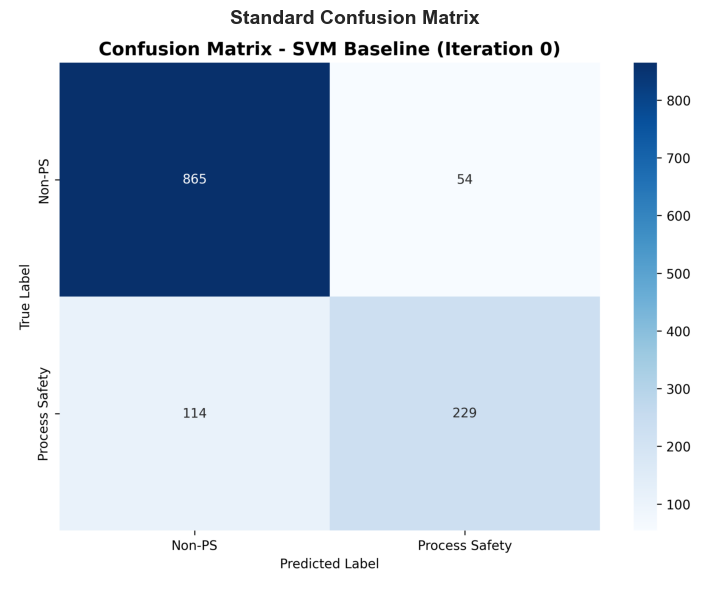


Normalized Confusion Matrix: confusion_matrix_normalized_iteration_0.png


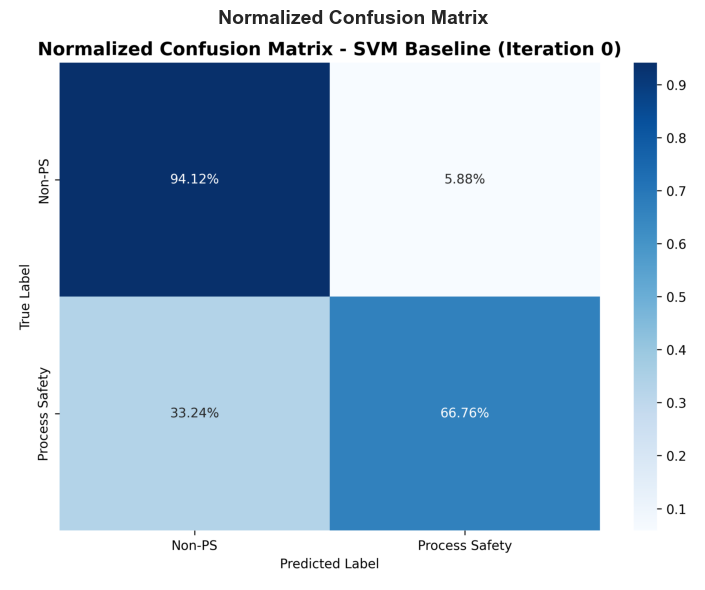


4. PERFORMANCE METRICS


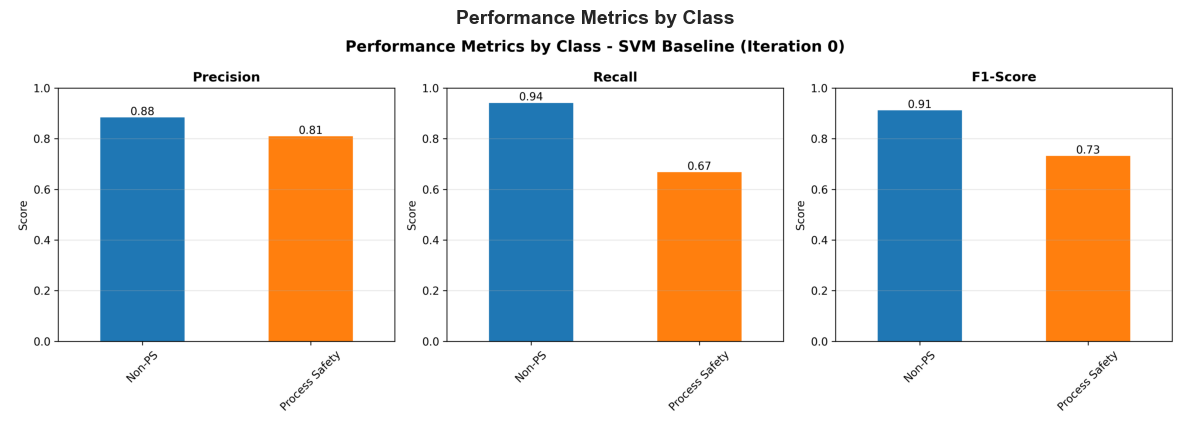


5. DATASET SUMMARY

English Dataset:
  Total samples     : 6,323
  Features          : ['TITLE', 'CASE_DESCRIPTION', 'CASENO', 'CASE_TYPE']

  Case Type Distribution:
    Safety                         :  3,606 (57.03%)
    Process Safety                 :  1,725 (27.28%)
    Environment                    :    538 ( 8.51%)
    Asset and Reputation damage/loss :    207 ( 3.27%)
    Operational loss               :    193 ( 3.05%)
    Information Security           :     18 ( 0.28%)

ITERATION 0 OUTPUT DISPLAY COMPLETE


In [163]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Use PATHS from earlier configuration (already cross-platform)
RESULTS_DIR = str(PATHS['results'])
DATA_DIR = str(PATHS['iteration_output'])
EMBEDDINGS_DIR = str(PATHS['embeddings'])

print("="*80)
print("ITERATION 0 - OUTPUT SUMMARY")
print("="*80)

# 1. Display file listings
print("\n" + "="*80)
print("1. GENERATED FILES")
print("="*80)

for label, directory in [("Data Files", DATA_DIR), ("Embeddings", EMBEDDINGS_DIR), ("Results", RESULTS_DIR)]:
    print(f"\n{label}: {directory}")
    if os.path.exists(directory):
        files = os.listdir(directory)
        for file in sorted(files):
            file_path = os.path.join(directory, file)
            size = os.path.getsize(file_path) / (1024 * 1024)  # MB
            print(f"   {file:<50} ({size:.2f} MB)")
    else:
        print("   Directory not found")

# 2. Load and display summary statistics with formatted output
print("\n" + "="*80)
print("2. BASELINE MODEL SUMMARY STATISTICS")
print("="*80)

summary_csv = os.path.join(RESULTS_DIR, "iteration_0_baseline_summary.csv")
if os.path.exists(summary_csv):
    df_summary = pd.read_csv(summary_csv)
    print("\nKey Metrics:")
    for col in df_summary.columns:
        value = df_summary[col].values[0]
        print(f"  {col:<25} : {value}")
else:
    print("  Summary CSV not found")

# Display Classification Report and Confusion Matrix in formatted output
print("\n" + "-"*80)
print("Classification Report & Confusion Matrix Summary")
print("-"*80 + "\n")

report_file = os.path.join(RESULTS_DIR, "classification_report_iteration_0.txt")
if os.path.exists(report_file):
    with open(report_file, 'r') as f:
        report_content = f.read()
    # Extract the classification report section
    lines = report_content.split('\n')
    for line in lines:
        if 'precision' in line or 'Non-PS' in line or 'Process Safety' in line or 'accuracy' in line or 'macro avg' in line or 'weighted avg' in line:
            print(line)

# Calculate confusion matrix metrics from the baseline summary
print("\n")
tn = df_summary['Support_Non_PS'].values[0] * (df_summary['Recall_Non_PS'].values[0])
fp = df_summary['Support_Non_PS'].values[0] * (1 - df_summary['Recall_Non_PS'].values[0])
fn = df_summary['Support_PS'].values[0] * (1 - df_summary['Recall_PS'].values[0])
tp = df_summary['Support_PS'].values[0] * (df_summary['Recall_PS'].values[0])

# Round to nearest integer
tn, fp, fn, tp = int(round(tn)), int(round(fp)), int(round(fn)), int(round(tp))

print("Confusion Matrix:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")

# Calculate summary metrics
accuracy = df_summary['Accuracy'].values[0]
f1_non_ps = df_summary['F1_Non_PS'].values[0]
f1_ps = df_summary['F1_PS'].values[0]
macro_f1 = (f1_non_ps + f1_ps) / 2
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"FNR: {fnr:.4f}")

# 3. Display confusion matrix images
print("\n" + "="*80)
print("3. CONFUSION MATRIX VISUALIZATIONS")
print("="*80)

cm_files = [
    ("confusion_matrix_iteration_0.png", "Standard Confusion Matrix"),
    ("confusion_matrix_normalized_iteration_0.png", "Normalized Confusion Matrix")
]

for filename, title in cm_files:
    filepath = os.path.join(RESULTS_DIR, filename)
    if os.path.exists(filepath):
        print(f"\n{title}: {filename}")
        img = Image.open(filepath)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=14, weight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f"   {filename} not found")

# 4. Display performance metrics chart
print("\n" + "="*80)
print("4. PERFORMANCE METRICS")
print("="*80)

metrics_file = os.path.join(RESULTS_DIR, "performance_metrics_iteration_0.png")
if os.path.exists(metrics_file):
    img = Image.open(metrics_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Performance Metrics by Class", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("   Performance metrics image not found")

# 5. Dataset summary
print("\n" + "="*80)
print("5. DATASET SUMMARY")
print("="*80)

english_csv = os.path.join(DATA_DIR, "english_dataset_langdetect.csv")
if os.path.exists(english_csv):
    df_eng = pd.read_csv(english_csv)
    print(f"\nEnglish Dataset:")
    print(f"  Total samples     : {len(df_eng):,}")
    print(f"  Features          : {list(df_eng.columns)}")
    print(f"\n  Case Type Distribution:")
    for case_type, count in df_eng['CASE_TYPE'].value_counts().items():
        pct = (count / len(df_eng)) * 100
        print(f"    {case_type:<30} : {count:>6,} ({pct:>5.2f}%)")
else:
    print("  English dataset CSV not found")

print("\n" + "="*80)
print("ITERATION 0 OUTPUT DISPLAY COMPLETE")
print("="*80)

In [194]:

# FAST SVM RETRAINING (without regenerating embeddings)
# Load pre-computed embeddings and retrain SVM with current MODEL_CONFIG

import pickle
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

print("Loading pre-computed BERT embeddings...")
pkl_path = PATHS['embeddings'] / 'english_dataset_bert_embeddings.pkl'

with open(pkl_path, 'rb') as f:
    embedding_data = pickle.load(f)

X_train = embedding_data['X_train']
X_test = embedding_data['X_test']
y_train = embedding_data['y_train']
y_test = embedding_data['y_test']

print(f"✓ Embeddings loaded: {X_train.shape}, {X_test.shape}")

# Train SVM with current MODEL_CONFIG
print(f"\nTraining SVM with C={MODEL_CONFIG['C']}, class_weights={MODEL_CONFIG['class_weights']}...")
svm_model = SVC(
    kernel=MODEL_CONFIG['kernel'],
    C=MODEL_CONFIG['C'],
    gamma=MODEL_CONFIG['gamma'],
    probability=MODEL_CONFIG['probability'],
    random_state=MODEL_CONFIG['random_state'],
    class_weight=MODEL_CONFIG['class_weights']
)

svm_model.fit(X_train, y_train)
print("✓ SVM trained")

# Evaluate
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)
macro_f1 = (f1[0] + f1[1]) / 2

print(f"\n=== RESULTS ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Non-PS: {f1[0]:.4f}")
print(f"F1 PS: {f1[1]:.4f}")
print(f"Macro F1: {macro_f1:.4f}")


Loading pre-computed BERT embeddings...
✓ Embeddings loaded: (5058, 768), (1265, 768)

Training SVM with C=0.62, class_weights=None...
✓ SVM trained

=== RESULTS ===
Accuracy: 0.8419
F1 Non-PS: 0.8946
F1 PS: 0.6835
Macro F1: 0.7891


In [153]:
"""
================================================================================
SVM BASELINE MODEL TRAINING & COMPREHENSIVE EVALUATION
================================================================================
Train Support Vector Machine classifier on BERT embeddings with:
1. Baseline model training
2. K-Fold cross-validation
3. Comprehensive performance metrics
4. Advanced visualizations (ROC-AUC, PR-Curve)
5. Model interpretation

Rationale for SVM:
- Effective for high-dimensional data (768D embeddings)
- Excellent generalization with small-to-medium datasets
- Mathematically well-understood and interpretable
- Fast inference and training
================================================================================
"""

logger.info("\n" + "="*80)
logger.info("SVM BASELINE MODEL TRAINING")
logger.info("="*80)

logger.info("\n" + "-"*80)
logger.info("Loading Embeddings")
logger.info("-"*80)

try:
    pkl_path = PATHS['embeddings'] / 'english_dataset_bert_embeddings.pkl'
    
    with open(pkl_path, 'rb') as f:
        embedding_data = pickle.load(f)
    
    X_train = embedding_data['X_train']
    X_test = embedding_data['X_test']
    y_train = embedding_data['y_train']
    y_test = embedding_data['y_test']
    
    logger.info(f"  Embeddings loaded: {pkl_path}")
    logger.info(f"  Training set: {X_train.shape}")
    logger.info(f"  Test set: {X_test.shape}")
    
except Exception as e:
    logger.error(f"✗ Error loading embeddings: {str(e)}")
    raise

logger.info("\n" + "-"*80)
logger.info("STEP 4.2: Training Baseline SVM Model")
logger.info("-"*80)

try:
    # Initialize SVM with balanced class weights to handle imbalance
    svm_model = SVC(
        kernel=MODEL_CONFIG['kernel'],
        C=MODEL_CONFIG['C'],
        gamma=MODEL_CONFIG['gamma'],
        probability=MODEL_CONFIG['probability'],
        random_state=MODEL_CONFIG['random_state'],
        class_weight=MODEL_CONFIG['class_weights']
    )
    
    logger.info("Training SVM...")
    svm_model.fit(X_train, y_train)
    
    logger.info(f"  Model trained successfully")
    logger.info(f"  Algorithm: {MODEL_CONFIG['algorithm']} ({MODEL_CONFIG['kernel']} kernel)")
    logger.info(f"  C (regularization): {MODEL_CONFIG['C']}")
    logger.info(f"  Class weights: {MODEL_CONFIG['class_weights']}")
    
except Exception as e:
    logger.error(f"  Error training SVM: {str(e)}")
    raise

logger.info("\n" + "-"*80)
logger.info("Baseline Evaluation on Test Set")
logger.info("-"*80)

try:
    # Predictions
    y_pred = svm_model.predict(X_test)
    y_pred_proba = svm_model.predict_proba(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    
    logger.info(f"  Evaluation complete")
    logger.info(f"\n  BASELINE METRICS:")
    logger.info(f"  Accuracy:  {accuracy:.4f}")
    logger.info(f"  ROC-AUC:   {roc_auc:.4f}")
    logger.info(f"\n  Class 0 (Non-PS):")
    logger.info(f"    Precision: {precision[0]:.4f}")
    logger.info(f"    Recall:    {recall[0]:.4f}")
    logger.info(f"    F1-Score:  {f1[0]:.4f}")
    logger.info(f"\n  Class 1 (Process Safety):")
    logger.info(f"    Precision: {precision[1]:.4f}")
    logger.info(f"    Recall:    {recall[1]:.4f}")
    logger.info(f"    F1-Score:  {f1[1]:.4f}")
    
except Exception as e:
    logger.error(f"  Error evaluating model: {str(e)}")
    raise

logger.info("\n" + "-"*80)
logger.info("Cross-Validation (K-Fold)")
logger.info("-"*80)

try:
    cv_folds = EVAL_CONFIG['cv_folds']
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=MODEL_CONFIG['random_state'])
    
    # Combine train+test for CV
    X_combined = np.vstack([X_train, X_test])
    y_combined = np.concatenate([y_train, y_test])
    
    cv_results = cross_validate(
        svm_model,
        X_combined,
        y_combined,
        cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True
    )
    
    logger.info(f"  {cv_folds}-Fold Cross-Validation complete")
    logger.info(f"\n  CV RESULTS (Test Fold Means):")
    logger.info(f"  Accuracy:  {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
    logger.info(f"  Precision: {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std():.4f})")
    logger.info(f"  Recall:    {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std():.4f})")
    logger.info(f"  F1-Score:  {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std():.4f})")
    logger.info(f"  ROC-AUC:   {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")
    
except Exception as e:
    logger.error(f"  Error during cross-validation: {str(e)}")

logger.info("\n" + "-"*80)
logger.info("Generating Classification Report")
logger.info("-"*80)

try:
    class_labels = EVAL_CONFIG['class_labels']
    report = classification_report(y_test, y_pred, target_names=class_labels, digits=2, output_dict=True)
    
    logger.info(f"  Classification report generated")
    logger.info(f"\n{classification_report(y_test, y_pred, target_names=class_labels, digits=2)}")
    
except Exception as e:
    logger.error(f"  Error generating report: {str(e)}")

logger.info("\n" + "-"*80)
logger.info("Saving Model & Results")
logger.info("-"*80)

try:
    # Save model
    model_path = PATHS['results'] / 'svm_baseline_model.joblib'
    joblib.dump(svm_model, model_path)
    logger.info(f"  Model saved: {model_path}")
    
    # Save results
    results_dict = {
        'model_params': MODEL_CONFIG,
        'test_metrics': {
            'accuracy': float(accuracy),
            'roc_auc': float(roc_auc),
            'precision': precision.tolist(),
            'recall': recall.tolist(),
            'f1': f1.tolist(),
            'support': support.tolist()
        },
        'cv_metrics': {
            'accuracy': cv_results['test_accuracy'].mean(),
            'precision': cv_results['test_precision'].mean(),
            'recall': cv_results['test_recall'].mean(),
            'f1': cv_results['test_f1'].mean(),
            'roc_auc': cv_results['test_roc_auc'].mean()
        },
        'timestamp': datetime.now().isoformat()
    }
    
    results_json = PATHS['results'] / 'baseline_results.json'
    with open(results_json, 'w') as f:
        json.dump(results_dict, f, indent=2)
    
    logger.info(f"  Results saved: {results_json}")
    
except Exception as e:
    logger.error(f"  Error saving results: {str(e)}")

logger.info("\n" + "="*80)
logger.info("MODEL TRAINING & EVALUATION COMPLETE")
logger.info("="*80)

2026-01-28 20:20:14 - Iteration_0 - INFO - 
2026-01-28 20:20:14 - Iteration_0 - INFO - SVM BASELINE MODEL TRAINING
2026-01-28 20:20:14 - Iteration_0 - INFO - ================================================================================
2026-01-28 20:20:14 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:20:14 - Iteration_0 - INFO - Loading Embeddings
2026-01-28 20:20:14 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:20:14 - Iteration_0 - INFO -   Embeddings loaded: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/Embeddings/_iteration_0/bert-base-uncased/english_dataset_bert_embeddings.pkl
2026-01-28 20:20:14 - Iteration_0 - INFO -   Training set: (5051, 768)
2026-01-28 20:20:14 - Iteration_0 - INFO -   Test set: (1263, 768)
2026-01-28 20:20:14 - Iteration_0 - INFO - 
----------------------------------------------------------

In [154]:
"""
================================================================================
COMPREHENSIVE VISUALIZATIONS & ANALYSIS
================================================================================
Generate visualizations for model evaluation:
1. Confusion matrices (standard and normalized)
2. ROC-AUC curves
3. Precision-Recall curves
4. Performance metrics comparison
5. Classification report
================================================================================
"""

logger.info("\n" + "="*80)
logger.info("ADVANCED VISUALIZATIONS")
logger.info("="*80)

logger.info("\n" + "-"*80)
logger.info("Confusion Matrix Visualizations")
logger.info("-"*80)

try:
    cm = confusion_matrix(y_test, y_pred)
    
    # Standard confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6), dpi=EVAL_CONFIG['dpi'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=EVAL_CONFIG['class_labels'], 
                yticklabels=EVAL_CONFIG['class_labels'],
                cbar_kws={'label': 'Count'}, ax=ax)
    ax.set_title('Confusion Matrix - SVM Baseline', fontsize=14, weight='bold')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    
    cm_path = PATHS['results'] / 'confusion_matrix.png'
    plt.savefig(cm_path, dpi=EVAL_CONFIG['dpi'], bbox_inches='tight')
    plt.close()
    logger.info(f"   Saved: {cm_path}")
    
    # Normalized confusion matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=EVAL_CONFIG['dpi'])
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=EVAL_CONFIG['class_labels'],
                yticklabels=EVAL_CONFIG['class_labels'],
                cbar_kws={'label': 'Percentage'}, ax=ax)
    ax.set_title('Normalized Confusion Matrix - SVM Baseline', fontsize=14, weight='bold')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    
    cm_norm_path = PATHS['results'] / 'confusion_matrix_normalized.png'
    plt.savefig(cm_norm_path, dpi=EVAL_CONFIG['dpi'], bbox_inches='tight')
    plt.close()
    logger.info(f"   Saved: {cm_norm_path}")
    
except Exception as e:
    logger.error(f"  Error creating confusion matrices: {str(e)}")

logger.info("\n" + "-"*80)
logger.info("  ROC-AUC & Precision-Recall Curves")
logger.info("-"*80)

try:
    # ROC-AUC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
    roc_auc = auc(fpr, tpr)
    
    # Precision-Recall curve
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
    pr_auc = auc(recall_curve, precision_curve)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=EVAL_CONFIG['dpi'])
    
    # ROC curve
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=11)
    axes[0].set_ylabel('True Positive Rate', fontsize=11)
    axes[0].set_title('ROC-AUC Curve', fontsize=12, weight='bold')
    axes[0].legend(loc="lower right", fontsize=10)
    axes[0].grid(alpha=0.3)
    
    # Precision-Recall curve
    axes[1].plot(recall_curve, precision_curve, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    axes[1].axhline(y=y_test.sum()/len(y_test), color='red', lw=2, linestyle='--', label='Baseline (Random)')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall', fontsize=11)
    axes[1].set_ylabel('Precision', fontsize=11)
    axes[1].set_title('Precision-Recall Curve', fontsize=12, weight='bold')
    axes[1].legend(loc="upper right", fontsize=10)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    curves_path = PATHS['results'] / 'roc_pr_curves.png'
    plt.savefig(curves_path, dpi=EVAL_CONFIG['dpi'], bbox_inches='tight')
    plt.close()
    logger.info(f"    Saved: {curves_path}")
    
except Exception as e:
    logger.error(f"  Error creating curves: {str(e)}")

logger.info("\n" + "-"*80)
logger.info("STEP 5.3: Performance Metrics Bar Charts")
logger.info("-"*80)

try:
    metrics_data = pd.DataFrame({
        EVAL_CONFIG['class_labels'][0]: [precision[0], recall[0], f1[0]],
        EVAL_CONFIG['class_labels'][1]: [precision[1], recall[1], f1[1]]
    }, index=['Precision', 'Recall', 'F1-Score'])
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=EVAL_CONFIG['dpi'])
    
    for idx, metric in enumerate(['Precision', 'Recall', 'F1-Score']):
        ax = axes[idx]
        metrics_data.loc[metric].plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'], width=0.7)
        ax.set_title(f'{metric}', fontsize=12, weight='bold')
        ax.set_ylabel('Score', fontsize=11)
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        
        # Add value labels
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.suptitle('Performance Metrics by Class', fontsize=14, weight='bold', y=1.02)
    plt.tight_layout()
    
    metrics_path = PATHS['results'] / 'performance_metrics.png'
    plt.savefig(metrics_path, dpi=EVAL_CONFIG['dpi'], bbox_inches='tight')
    plt.close()
    logger.info(f"   Saved: {metrics_path}")
    
except Exception as e:
    logger.error(f"  Error creating metrics chart: {str(e)}")

logger.info("\n" + "-"*80)
logger.info(" Saving Classification Report as Text")
logger.info("-"*80)

try:
    report_text = classification_report(y_test, y_pred, target_names=EVAL_CONFIG['class_labels'], digits=4)
    
    report_path = PATHS['results'] / 'classification_report.txt'
    with open(report_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("ITERATION 0 - SVM BASELINE MODEL EVALUATION REPORT\n")
        f.write("="*80 + "\n\n")
        f.write("MODEL PARAMETERS:\n")
        for key, val in MODEL_CONFIG.items():
            f.write(f"  {key}: {val}\n")
        f.write(f"\nDATASET INFORMATION:\n")
        f.write(f"  Embedding Model: {EMBEDDING_CONFIG['model_name']}\n")
        f.write(f"  Embedding Dimension: {EMBEDDING_CONFIG['embedding_dim']}\n")
        f.write(f"  Training Samples: {len(X_train):,}\n")
        f.write(f"  Test Samples: {len(X_test):,}\n")
        f.write(f"\nCLASSIFICATION REPORT:\n")
        f.write("="*80 + "\n")
        f.write(report_text)
        f.write("\n" + "="*80 + "\n")
    
    logger.info(f"    Saved: {report_path}")
    
except Exception as e:
    logger.error(f"  Error saving report: {str(e)}")

logger.info("\n" + "="*80)
logger.info("VISUALIZATIONS GENERATED")
logger.info("="*80)

2026-01-28 20:23:17 - Iteration_0 - INFO - 
2026-01-28 20:23:17 - Iteration_0 - INFO - ADVANCED VISUALIZATIONS
2026-01-28 20:23:17 - Iteration_0 - INFO - ================================================================================
2026-01-28 20:23:17 - Iteration_0 - INFO - 
--------------------------------------------------------------------------------
2026-01-28 20:23:17 - Iteration_0 - INFO - Confusion Matrix Visualizations
2026-01-28 20:23:17 - Iteration_0 - INFO - --------------------------------------------------------------------------------
2026-01-28 20:23:17 - Iteration_0 - INFO -    Saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/confusion_matrix.png
2026-01-28 20:23:17 - Iteration_0 - INFO -    Saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/confusion_matrix_normalized.png
2026-01-28 20:23:17 - Iteration_0 - INFO - 
------------------------------------------------------------------------------

In [155]:
"""
================================================================================
ITERATION 0 - FINAL SUMMARY & CHECKPOINT
================================================================================
Comprehensive summary of iteration 0 results for documentation and comparison
with future iterations.
================================================================================
"""

logger.info("\n" + "="*80)
logger.info("FINAL SUMMARY REPORT")
logger.info("="*80)

try:
    # Create comprehensive summary report
    summary_report = {
        'iteration': 0,
        'timestamp': datetime.now().isoformat(),
        'pipeline_stages': {
            '1_data_loading': {
                'description': 'Loaded 3 raw datasets',
                'files': list(DATA_FILES.values()),
                'total_records': sum([len(df_14), len(df_28), len(df_700)])
            },
            '2_language_detection': {
                'description': 'Filtered to English language records',
                'total_records': len(master_df_0),
                'english_records': len(english_dataset),
                'english_percentage': f"{(len(english_dataset)/len(master_df_0)*100):.2f}%"
            },
            '3_embeddings': {
                'description': 'Generated BERT embeddings',
                'model': EMBEDDING_CONFIG['model_name'],
                'dimension': EMBEDDING_CONFIG['embedding_dim'],
                'samples': len(df),
                'train_samples': len(X_train),
                'test_samples': len(X_test)
            },
            '4_model_training': {
                'description': 'Trained SVM baseline classifier',
                'algorithm': MODEL_CONFIG['algorithm'],
                'kernel': MODEL_CONFIG['kernel'],
                'class_weights': MODEL_CONFIG['class_weights']
            }
        },
        'baseline_metrics': {
            'accuracy': f"{accuracy:.4f}",
            'roc_auc': f"{roc_auc:.4f}",
            'class_0_precision': f"{precision[0]:.4f}",
            'class_0_recall': f"{recall[0]:.4f}",
            'class_0_f1': f"{f1[0]:.4f}",
            'class_1_precision': f"{precision[1]:.4f}",
            'class_1_recall': f"{recall[1]:.4f}",
            'class_1_f1': f"{f1[1]:.4f}"
        },
        'output_artifacts': {
            'master_dataset': str(PATHS['iteration_output'] / 'master_df_0.csv'),
            'english_dataset': str(PATHS['iteration_output'] / 'english_dataset_langdetect.csv'),
            'embeddings': str(PATHS['embeddings'] / 'english_dataset_bert_embeddings.pkl'),
            'model': str(PATHS['results'] / 'svm_baseline_model.joblib'),
            'results_json': str(PATHS['results'] / 'baseline_results.json'),
            'classification_report': str(PATHS['results'] / 'classification_report.txt'),
            'confusion_matrix': str(PATHS['results'] / 'confusion_matrix.png'),
            'roc_pr_curves': str(PATHS['results'] / 'roc_pr_curves.png'),
            'metrics_chart': str(PATHS['results'] / 'performance_metrics.png')
        }
    }
    
    # Save summary report
    summary_path = PATHS['results'] / 'iteration_0_summary.json'
    with open(summary_path, 'w') as f:
        json.dump(summary_report, f, indent=2)
    
    logger.info(f"  Summary report generated: {summary_path}")
    
    # Display summary
    logger.info("\n" + "="*80)
    logger.info("ITERATION 0 - KEY RESULTS")
    logger.info("="*80)
    logger.info(f"\nDATA PROCESSING:")
    logger.info(f"  Raw records loaded: {summary_report['pipeline_stages']['1_data_loading']['total_records']:,}")
    logger.info(f"  Master dataset: {summary_report['pipeline_stages']['2_language_detection']['total_records']:,} records")
    logger.info(f"  English records: {summary_report['pipeline_stages']['2_language_detection']['english_records']:,} ({summary_report['pipeline_stages']['2_language_detection']['english_percentage']})")
    
    logger.info(f"\nEMBEDDINGS:")
    logger.info(f"  Model: {EMBEDDING_CONFIG['model_name']}")
    logger.info(f"  Dimension: {EMBEDDING_CONFIG['embedding_dim']}")
    logger.info(f"  Samples: {len(df):,}")
    
    logger.info(f"\nMODEL PERFORMANCE:")
    logger.info(f"  Accuracy:  {accuracy:.4f}")
    logger.info(f"  ROC-AUC:   {roc_auc:.4f}")
    logger.info(f"  Class 0 (Non-PS) F1-Score:  {f1[0]:.4f}")
    logger.info(f"  Class 1 (Process Safety) F1-Score:  {f1[1]:.4f}")
    
    logger.info(f"\nOUTPUT ARTIFACTS:")
    for artifact_name, artifact_path in summary_report['output_artifacts'].items():
        path_obj = Path(artifact_path)
        if path_obj.exists():
            size = path_obj.stat().st_size
            if size > 1024*1024:
                size_str = f"{size / (1024*1024):.2f} MB"
            else:
                size_str = f"{size / 1024:.2f} KB"
            logger.info(f"    {artifact_name}: {size_str}")
    
except Exception as e:
    logger.error(f"  Error creating summary report: {str(e)}")

logger.info("\n" + "="*80)
logger.info("ITERATION 0 - PIPELINE COMPLETE")
logger.info("="*80)
logger.info(f"Execution completed at: {datetime.now().isoformat()}")
logger.info("="*80)

2026-01-28 20:23:18 - Iteration_0 - INFO - 
2026-01-28 20:23:18 - Iteration_0 - INFO - FINAL SUMMARY REPORT
2026-01-28 20:23:18 - Iteration_0 - INFO - ================================================================================
2026-01-28 20:23:18 - Iteration_0 - ERROR -   Error creating summary report: Object of type PosixPath is not JSON serializable
2026-01-28 20:23:18 - Iteration_0 - INFO - 
2026-01-28 20:23:18 - Iteration_0 - INFO - ITERATION 0 - PIPELINE COMPLETE
2026-01-28 20:23:18 - Iteration_0 - INFO - ================================================================================
2026-01-28 20:23:18 - Iteration_0 - INFO - Execution completed at: 2026-01-28T20:23:18.029977
2026-01-28 20:23:18 - Iteration_0 - INFO - ================================================================================
